# Tutorial: SCARLET workflow from raw data

This notebook presents a complete, tutorial-style workflow to:
- initialize a `WorkflowContext` from a raw-data directory,
- inspect detected runs and configurations,
- generate the `refs_sub` and `refs_norm` reference files,
- correct the normalization references,
- compute transmissions,
- produce the final `I(q)` text files.

The idea is to keep a simple sequence throughout the notebook: **load, inspect, correct, reference, integrate**.


## 1. Environment setup

This first cell moves the notebook to the repository root and adds `src/` to the `PYTHONPATH`.
This is useful whether the notebook is launched from `notebooks/` or from the repository root.


In [1]:
from pathlib import Path
import os
import sys

# Detect the repository root and make sure src/ is importable.
ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

os.chdir(ROOT)
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f"Repository root: {ROOT}")
print(f"Python path includes: {SRC}")


Repository root: /home/achennev/python/scarlet
Python path includes: /home/achennev/python/scarlet/src


## 2. Define the working paths

Here we define:
- the raw-data directory,
- the output directory,
- the instrument name used for conversion and file interpretation.


In [2]:
from scarlet.workflow.context import initialize_workflow_context_from_raw_directory

# Adapt these paths to your own experiment if needed.
RAW_DIR = ROOT / "data" / "SANSLLB" / "raw"
OUTPUT_DIR = ROOT / "data" / "SANSLLB" / "out"
INSTRUMENT_NAME = "sansllb"

RAW_DIR, OUTPUT_DIR


(PosixPath('/home/achennev/python/scarlet/data/SANSLLB/raw'),
 PosixPath('/home/achennev/python/scarlet/data/SANSLLB/out'))

## 3. Initialize the `WorkflowContext`

This step scans the raw files, converts what needs to be converted, detects runs,
builds the instrumental configurations, and stores everything in a `WorkflowContext` object.


In [3]:
# Build the workflow context from the raw-data directory.
w = initialize_workflow_context_from_raw_directory(
    RAW_DIR,
    instrument_name=INSTRUMENT_NAME,
    output_dir=OUTPUT_DIR,
    overwrite=True,
)

print(f"runs: {len(w.runs)}")
print(f"configurations: {len(w.configurations)}")
print(f"issues: {len(w.issues)}")
print(f"artifacts: {len(w.artifacts)}")


runs: 62
configurations: 2
issues: 4
artifacts: 64


## 4. Inspect the detected runs

The table below is useful to verify that each file has been classified with:
- a `config_id`,
- a `mode` (`scattering` or `transmission`),
- an `entity` (`sample`, `empty_cell`, `dark`, etc.).

This is a good checkpoint before generating the reference files.


In [4]:
w.runs_table()

sample_name,config_id,mode,entity,file_path
empty_beam_att5_ws_beamstop,config_1,transmission,empty_beam,/home/achennev/python/scarlet/data/SANSLLB/out/sans-llb2025n002339.nxs
empty_cell,config_1,transmission,empty_cell,/home/achennev/python/scarlet/data/SANSLLB/out/sans-llb2025n002341.nxs
H2O,config_1,transmission,sample,/home/achennev/python/scarlet/data/SANSLLB/out/sans-llb2025n002342.nxs
S1_P_PB_25_2mm,config_1,transmission,sample,/home/achennev/python/scarlet/data/SANSLLB/out/sans-llb2025n002343.nxs
S2_P_PB_60_2mm,config_1,transmission,sample,/home/achennev/python/scarlet/data/SANSLLB/out/sans-llb2025n002344.nxs
S3_P_PBK_40_2_2mm,config_1,transmission,sample,/home/achennev/python/scarlet/data/SANSLLB/out/sans-llb2025n002345.nxs
S4_P_BC_25_2mm,config_1,transmission,sample,/home/achennev/python/scarlet/data/SANSLLB/out/sans-llb2025n002346.nxs
S5_P_BC_60_2mm,config_1,transmission,sample,/home/achennev/python/scarlet/data/SANSLLB/out/sans-llb2025n002347.nxs
S6_P_BCK_40_2_2mm,config_1,transmission,sample,/home/achennev/python/scarlet/data/SANSLLB/out/sans-llb2025n002348.nxs
S7_P_MI_25_1mm,config_1,transmission,sample,/home/achennev/python/scarlet/data/SANSLLB/out/sans-llb2025n002349.nxs


## 5. Inspect the configurations

This table summarizes the instrumental properties detected for each configuration:
wavelength, sample-to-detector distance, collimation, apertures, and related metadata.


In [5]:
w.configurations_table()

config_id,wavelength,sample_detector_distance,notes,has_collimation,collimation_distance,last_aperture_to_sample_distance,aperture1_type,aperture1_x_gap,aperture1_y_gap,aperture1_diameter,aperture2_type,aperture2_x_gap,aperture2_y_gap,aperture2_diameter
config_1,6.00046,"2.5, 1.00001, 1.00001",,True,0.5,1.2,slit,0.0419996,0.0419996,,slit,0.0319997,0.0320003,
config_2,5.9989,"9, 3.59999, 3.59999",,True,2.58333,1.2,slit,0.0269997,0.0269999,,slit,0.0169996,0.0169998,


## 6. Generate the reference files

At this stage we create, for each configuration:
- one `refs_sub` file for subtraction,
- one `refs_norm` file for normalization.

These files gather the experimental references into a single format that is easier to reuse later.


In [6]:
from scarlet.workflow.context import generate_reference_files_from_workflow_context

# Generate refs_sub and refs_norm for every detected configuration.
generate_reference_files_from_workflow_context(w)
print("refs_sub:", {k: str(v) for k, v in sorted(w.refs_sub_files.items())})
print("refs_norm:", {k: str(v) for k, v in sorted(w.refs_norm_files.items())})


refs_sub: {'config_1': '/home/achennev/python/scarlet/data/SANSLLB/out/refs_sub_config_1.nxs', 'config_2': '/home/achennev/python/scarlet/data/SANSLLB/out/refs_sub_config_2.nxs'}
refs_norm: {'config_1': '/home/achennev/python/scarlet/data/SANSLLB/out/refs_norm_config_1.nxs', 'config_2': '/home/achennev/python/scarlet/data/SANSLLB/out/refs_norm_config_2.nxs'}


## 7. Update the beam center for `detector0`

The transmission detector beam center can be re-estimated from the
`empty_beam_transmission` image by using the center of mass of the transmission ROI.

This step updates the `refs_sub` files that were just generated.


In [7]:
from scarlet.workflow import update_detector0_beam_center_from_empty_beam_transmission

# Update detector0 beam center in each refs_sub from the empty-beam transmission frame.
for config_id, refs_sub_path in sorted(w.refs_sub_files.items()):
    update_detector0_beam_center_from_empty_beam_transmission(refs_sub_path)
    print(config_id, refs_sub_path)


config_1 /home/achennev/python/scarlet/data/SANSLLB/out/refs_sub_config_1.nxs
config_2 /home/achennev/python/scarlet/data/SANSLLB/out/refs_sub_config_2.nxs


### Optional manual override of the beam center

If the automatic center-of-mass estimate is not satisfactory, you can manually
set the beam center for a given configuration and detector.

This updates both the `refs_sub` and the `refs_norm` files associated with the
selected configuration.


In [8]:
# Example: manually override one beam center.
# Replace the configuration id, detector number, and coordinates with your values.
# w.update_beam_center("config_1", 1, -80, 63)


## 8. Optional manual mask editing

If needed, the graphical editor can be used to draw detector masks.
The cell remains commented out to avoid opening the GUI by mistake.


In [9]:
from scarlet.gui import run_mask_editor

# Uncomment to launch the GUI mask editor on a given raw NeXus file.
# run_mask_editor()


## 9. Export the runs table to CSV

The `runs_report.csv` file is useful if you want to manually adjust:
- sample names,
- `entity` values,
- `mode` values,
- or remove rows that should not remain in the workflow.


In [10]:
from scarlet.workflow.context import write_runs_report_csv


In [11]:
# Example: reload the workflow after manually editing the CSV file.
# from scarlet.workflow.context import update_workflow_context_from_runs_report_csv
# update_workflow_context_from_runs_report_csv(w, "data/SANSLLB/out/runs_report_modified.csv")
# update_workflow_context_from_runs_report_csv(w, "data/SANSLLB/out/runs_report.csv")
# file = write_runs_report_csv(w, csv_path="data/SANSLLB/out/runs_report_updated.csv", overwrite=True)


In [12]:
# Example: reload the workflow after manually editing the CSV.
# from scarlet.workflow.context import update_workflow_context_from_runs_report_csv
# update_workflow_context_from_runs_report_csv(w, "data/SANSLLB/out/runs_report_modified.csv")
# update_workflow_context_from_runs_report_csv(w, "data/SANSLLB/out/runs_report.csv")
# file = write_runs_report_csv(w, csv_path="data/SANSLLB/out/runs_report_updated.csv", overwrite=True)


## 10. Compute reference transmissions

Here we compute the scalar transmissions for the references embedded in the
`refs_sub` and `refs_norm` bundles, using the stored transmission ROI.


In [13]:
from scarlet.reduction.transmission import compute_reference_transmissions

# Compute and store reference transmissions inside refs_norm and refs_sub bundles.
for config_id, path in sorted(w.refs_norm_files.items()):
    compute_reference_transmissions(path)
    print("refs_norm", config_id, path)
for config_id, path in sorted(w.refs_sub_files.items()):
    compute_reference_transmissions(path)
    print("refs_sub", config_id, path)


refs_norm config_1 /home/achennev/python/scarlet/data/SANSLLB/out/refs_norm_config_1.nxs
refs_norm config_2 /home/achennev/python/scarlet/data/SANSLLB/out/refs_norm_config_2.nxs
refs_sub config_1 /home/achennev/python/scarlet/data/SANSLLB/out/refs_sub_config_1.nxs
refs_sub config_2 /home/achennev/python/scarlet/data/SANSLLB/out/refs_sub_config_2.nxs


## 11. Update masks in the reference files

If SCARLET mask files have been generated in `out/`, this step finds them and
injects them back into the matching `refs_sub` and `refs_norm` files.


In [ ]:
from scarlet.workflow import update_reference_masks_from_workflow_context

# Synchronize mask files found in the output directory back into refs_sub / refs_norm.
w = update_reference_masks_from_workflow_context(w)
w.masks_files

{}

## 12. Build `water_corrected` in the `refs_norm` files

This step prepares the final normalization reference from the water references,
including the required subtractions before the final solid-angle normalization in the reduction pipeline.


In [15]:
from scarlet.workflow import write_corrected_water_scattering

# Build and store the water_corrected reference in every refs_norm file.
for config_id, refs_norm_path in sorted(w.refs_norm_files.items()):
    write_corrected_water_scattering(refs_norm_path)
    print(config_id, refs_norm_path)


config_1 /home/achennev/python/scarlet/data/SANSLLB/out/refs_norm_config_1.nxs
config_2 /home/achennev/python/scarlet/data/SANSLLB/out/refs_norm_config_2.nxs


## 13. Save and reload the workflow context

The `WorkflowContext` can be serialized into a dedicated NeXus file, which makes it
possible to resume the processing later without starting again from scratch.


In [16]:
from scarlet.workflow import save_workflow_context, load_workflow_context

# Persist the workflow state and reload it to validate the round-trip.
save_workflow_context(w, "workflow_context.nxs")
w2 = load_workflow_context("workflow_context.nxs")


## 14. Compute sample transmissions

Using the sample transmission files together with the `refs_sub` bundles,
this step fills `w.transmissions` for the scattering treatment.


In [17]:
from scarlet.workflow.context import update_transmissions_from_workflow_context

# Compute sample transmissions for all configurations in the workflow.
update_transmissions_from_workflow_context(w)
w.transmissions_table()


sample_name,config_id,transmission
H2O,config_1,0.545957
H2O,config_2,0.592539
S10_P_BB_60_1mm,config_1,0.874308
S10_P_BB_60_1mm,config_2,0.986359
S11_P_EB_25_1mm,config_1,0.885527
S11_P_EB_25_1mm,config_2,0.998175
S12_P_EB_60_1mm,config_1,0.878189
S12_P_EB_60_1mm,config_2,0.983866
S1_P_PB_25_2mm,config_1,0.826591
S1_P_PB_25_2mm,config_2,0.925727


## 15. Final integration of the scattering files

This is the final tutorial step:
- monitor normalization,
- reference subtraction,
- division by `water_corrected`,
- solid-angle normalization,
- azimuthal averaging,
- writing the final `I(q)` text files.

Each detector produces its own output text file inside `w.output_dir`.


In [18]:
from scarlet.workflow import integrate_scattering_from_workflow_context

# Produce one I(q) text file per detector and per sample/configuration.
integrate_scattering_from_workflow_context(w, n_bins=100)


TypeError: PipelineData.__init__() got an unexpected keyword argument 'deadtime'

In [ ]:
from scarlet.workflow import ReductionPipeline, run_reduction_pipeline_from_workflow_context

pipeline = ReductionPipeline.default()
state = run_reduction_pipeline_from_workflow_context(
    w,
    n_bins=100,
    pipeline=pipeline,
    sample_name="S1_P_PB_25_2mm",
    config_id="config_1",
    detector_number=0,
)

state.integration.q

array([0.00185031, 0.00353041, 0.00530918, 0.00738859, 0.0093328 ,
       0.01107365, 0.01293082, 0.01480994, 0.01670124, 0.01859909,
       0.02041879, 0.02229504, 0.02417527, 0.0260781 , 0.02793962,
       0.02979287, 0.03169727, 0.0335693 , 0.03545126, 0.03729077,
       0.03913257, 0.04102161, 0.04292617, 0.044797  , 0.04664998,
       0.04848484, 0.05036683, 0.05229231, 0.05415334, 0.05599504,
       0.05785268, 0.05974219, 0.0616415 , 0.06353099, 0.06537278,
       0.06721418, 0.06910763, 0.07101059, 0.07286237, 0.07471223,
       0.07659363, 0.07848261, 0.08035722, 0.08221728, 0.08408301,
       0.08594879, 0.087836  , 0.08971343, 0.09157376, 0.09341929,
       0.09528365, 0.09717542, 0.09906944, 0.10096303, 0.10280892,
       0.10466306, 0.10654149, 0.10841995, 0.11027925, 0.11215099,
       0.11403154, 0.11591239, 0.11778836, 0.11965465, 0.12150908,
       0.12334601, 0.12524001, 0.12714686, 0.1290177 , 0.13087203,
       0.13274233, 0.13459962, 0.13645301, 0.13833446, 0.14020

Text(0, 0.5, 'I(q) (cm⁻¹)')

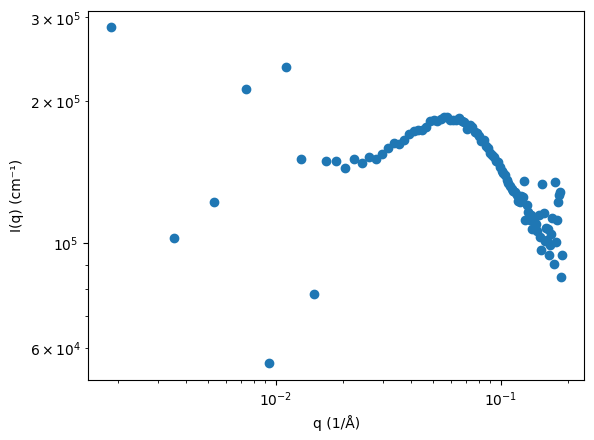

In [ ]:
import matplotlib.pyplot as plt
plt.loglog(state.integration.q, state.integration.intensity, marker="o", linestyle="")
plt.xlabel("q (1/Å)")
plt.ylabel("I(q) (cm⁻¹)")

In [ ]:
w.configurations['config_1']

Configuration(wavelength=6.000461656749349, sample_detector_distance=[2.5000035990000002, 1.0000053999, 1.0000053999], collimation=Collimation(aperture1=Aperture(type='slit', x_gap=0.041999600000000005, y_gap=0.041999600000000005, diameter=None), aperture2=Aperture(type='slit', x_gap=0.0319997, y_gap=0.032000299999999995, diameter=None), collimation_distance=0.5000000000000002, last_aperture_to_sample_distance=1.2), config_id='config_1', notes=None)